# MICrONS single-cell Allen-parameter transfer

This notebook changes **one thing** relative to the Allen reference test:

- the native Allen reconstruction is replaced by one processed MICrONS morphology (`model_node_id = 0`).

The Allen fitted membrane parameters and NMODL mechanisms are otherwise reused.

The custom BioNet processor **does not replace the MICrONS axon**. Therefore this is an Allen-derived **provisional parameter transfer**, not a fitted MICrONS e-model.


In [1]:
from microns20.config import find_project_root
from microns20.simulation import (
    compile_run_mechanisms,
    plot_voltage,
    prepare_microns_single_cell_run,
    run_microns_single_cell,
    simulation_spikes,
    validate_microns_single_cell_assets,
)

project_root = find_project_root()
project_root


PosixPath('<PROJECT_ROOT>')

## 1. Resolve the selected MICrONS cell

The morphology path is read from the processed morphology manifest rather than hard-coded.


In [2]:
cell = validate_microns_single_cell_assets(project_root)
cell


{'model_node_id': 0,
 'nucleus_id': 260303,
 'pt_root_id': 864691136275332030,
 'microns_mtype': 'L4a',
 'morphology_path': PosixPath('<PROJECT_ROOT>/data/processed/morphologies/model_000_nucleus_260303_root_864691136275332030.swc'),
 'morphology_name': 'model_000_nucleus_260303_root_864691136275332030.swc',
 'allen_source_dir': PosixPath('<PROJECT_ROOT>/data/external/allen_cell_types/487245719'),
 'fit_parameters': PosixPath('<PROJECT_ROOT>/data/external/allen_cell_types/487245719/fit_parameters.json'),
 'celsius': 34.0,
 'v_init_mv': -84.59716796875,
 'n_modfiles': 16}

## 2. Build a one-cell BioNet run

The generated run contains a copy of the selected MICrONS morphology, the Allen fit parameters, and the Allen mechanism sources.


In [3]:
run_info = prepare_microns_single_cell_run(
    project_root,
    overwrite=True,
)

run_info


{'model_node_id': 0,
 'nucleus_id': 260303,
 'pt_root_id': 864691136275332030,
 'microns_mtype': 'L4a',
 'morphology_path': PosixPath('<PROJECT_ROOT>/data/processed/morphologies/model_000_nucleus_260303_root_864691136275332030.swc'),
 'morphology_name': 'model_000_nucleus_260303_root_864691136275332030.swc',
 'allen_source_dir': PosixPath('<PROJECT_ROOT>/data/external/allen_cell_types/487245719'),
 'fit_parameters': PosixPath('<PROJECT_ROOT>/data/external/allen_cell_types/487245719/fit_parameters.json'),
 'celsius': 34.0,
 'v_init_mv': -84.59716796875,
 'n_modfiles': 16,
 'run_dir': PosixPath('<PROJECT_ROOT>/runs/microns_single_cell_model_00'),
 'config_file': PosixPath('<PROJECT_ROOT>/runs/microns_single_cell_model_00/config.json'),
 'network_dir': PosixPath('<PROJECT_ROOT>/runs/microns_single_cell_model_00/network'),
 'mechanisms_dir': PosixPath('<PROJECT_ROOT>/runs/microns_single_cell_model_00/components/mechanisms'),
 'population_name': 'microns_single_cell',
 'current_clamp_amp_na

## 3. Compile mechanisms inside this run

This creates a run-local `libnrnmech.so`, just as in the Allen reference test.


In [4]:
mechanism_library = compile_run_mechanisms(run_info)
mechanism_library


PosixPath('<PROJECT_ROOT>/runs/microns_single_cell_model_00/components/mechanisms/x86_64/libnrnmech.so')

## 4. Run the MICrONS cell

The registered processor applies the Allen perisomatic parameters while deliberately omitting BMTK's Allen axon-replacement step.


In [5]:
output_dir = run_microns_single_cell(run_info)
output_dir


2026-08-26 12:57:00,145 [INFO] Created log file


INFO:NEURONIOUtils:Created log file


2026-08-26 12:57:00,205 [INFO] Building cells.


INFO:NEURONIOUtils:Building cells.


2026-08-26 12:57:00,344 [INFO] Building recurrent connections


...

2026-08-26 12:57:00,843 [INFO]     step:10000 t_sim:1000.00 ms


INFO:NEURONIOUtils:    step:10000 t_sim:1000.00 ms


2026-08-26 12:57:00,849 [INFO] Simulation completed in 0.4955 seconds 


INFO:NEURONIOUtils:Simulation completed in 0.4955 seconds 


PosixPath('<PROJECT_ROOT>/runs/microns_single_cell_model_00/output')

## 5. Inspect spikes

In [6]:
spikes = simulation_spikes(run_info)
display(spikes)
print(f"Number of detected spikes: {len(spikes)}")


,node_ids,timestamps


Number of detected spikes: 0


## 6. Plot somatic membrane voltage

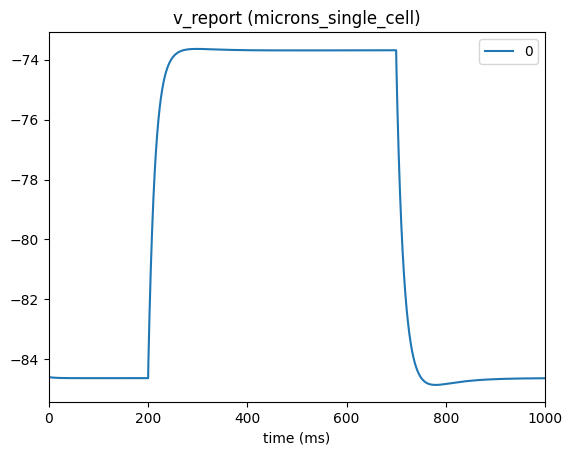

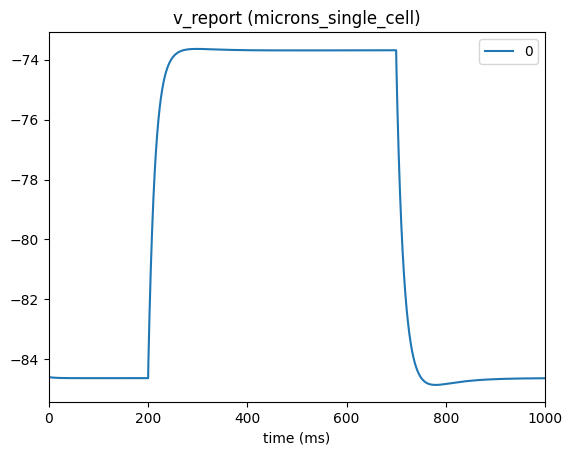

In [7]:
plot_voltage(run_info)
